# CMA Assignment #2 — Phase 1
Sentiment (Q1) and topic classification (Q2) on the BrandPulse dataset (600 posts × 3 brands).

Run on Colab with **GPU runtime** (Runtime → Change runtime type → GPU). Q2 on CPU takes 30+ minutes; on GPU it's about a minute per BART pass.


## Setup

In [ ]:
!pip install --quiet textblob emoji transformers accelerate
import nltk; nltk.download('punkt', quiet=True)

True

In [ ]:
import re, time, random
import numpy as np
import pandas as pd
import emoji
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_style("whitegrid")

DATA_PATH = "Team Assignment 2 Data 2026.csv"

BRAND_ORDER = ["LumoraBeauty", "FitPulse", "TechNest"]
BRAND_COLORS = {"LumoraBeauty": "#E59FB6", "FitPulse": "#F2A65A", "TechNest": "#5B8DEF"}
TOPIC_PALETTE = {"Informative": "#5B8DEF", "Entertaining": "#F2A65A", "Promotional": "#E59FB6"}
TOPICS = ["Informative", "Entertaining", "Promotional"]

In [ ]:
import torch
print(f"torch {torch.__version__}, cuda available: {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("Heads up: no GPU detected. Q2 will be slow.")

torch 2.10.0+cu128, cuda available: True


## Q0 — Load & inspect

In [ ]:
# On Colab? Upload the CSV here if it's not already in the session folder.
import os
if not os.path.exists(DATA_PATH):
    from google.colab import files
    files.upload()

In [ ]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print(df.shape)
df.sample(5)

(600, 9)


,Post_ID,Brand,Handle,Post_Text,Total_Followers,Total_Posts_LastYear,Num_Likes,Num_Comments,Num_Reposts
110,111,LumoraBeauty,@LumoraBeauty,Physical exfoliants use particles to buff skin...,485000,318,1683,74,160
419,420,TechNest,@TechNestHQ,Nothing hits like a clean desk setup ✨🖥️ Show ...,218000,194,1057,263,182
565,566,TechNest,@TechNestHQ,PCIe 5.0 SSDs are now available but current re...,218000,194,778,20,115
77,78,LumoraBeauty,@LumoraBeauty,Current mood: applying a sheet mask and preten...,485000,318,1856,453,647
181,182,LumoraBeauty,@LumoraBeauty,Introducing our bestselling Lumora Glow Serum ...,485000,318,4023,173,349


In [ ]:
print(df["Brand"].value_counts())
print("\nnulls per column:")
print(df.isna().sum())

Brand
LumoraBeauty    200
FitPulse        200
TechNest        200
Name: count, dtype: int64

nulls per column:
Post_ID                 0
Brand                   0
Handle                  0
Post_Text               0
Total_Followers         0
Total_Posts_LastYear    0
Num_Likes               0
Num_Comments            0
Num_Reposts             0
dtype: int64


In [ ]:
#df[["Num_Likes", "Num_Comments", "Num_Reposts"]].describe().round(1)
df["Num_Reposts"].describe().round(1)

,Num_Reposts
count,600.0
mean,359.4
std,291.9
min,41.0
25%,164.0
50%,281.0
75%,466.0
max,3327.0


In [ ]:
# Quick check on duplicates — turns out the 600 rows are built from ~145 unique
# post texts, each repeated 3-10 times with different engagement metrics.
n_unique = df["Post_Text"].nunique()
print(f"unique Post_Text values: {n_unique} (out of {len(df)} rows)")
df.groupby("Brand")["Post_Text"].nunique()

unique Post_Text values: 145 (out of 600 rows)


,Post_Text
Brand,
FitPulse,46
LumoraBeauty,51
TechNest,48


#### Distribution of Likes

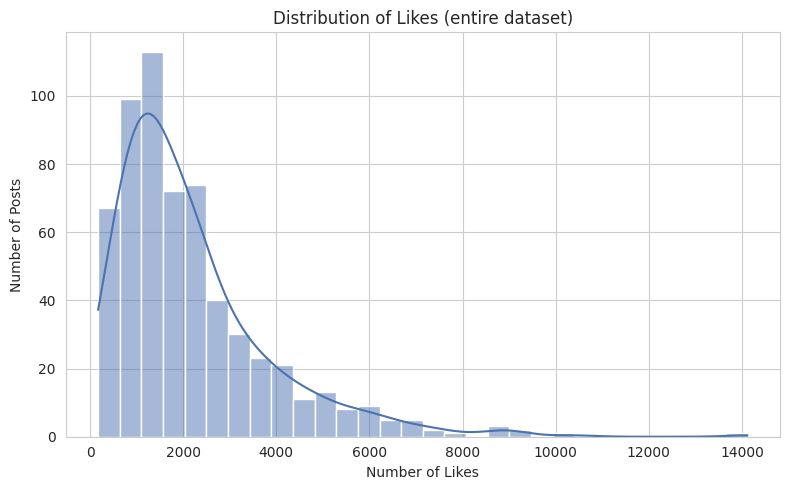

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["Num_Likes"], bins=30, kde=True, color="#4C72B0", edgecolor="white", ax=ax)
ax.set_xlabel("Number of Likes")
ax.set_ylabel("Number of Posts")
ax.set_title("Distribution of Likes (entire dataset)")
plt.tight_layout()
plt.savefig("likes_distribution_entire_dataset.png", dpi=150)
plt.show()

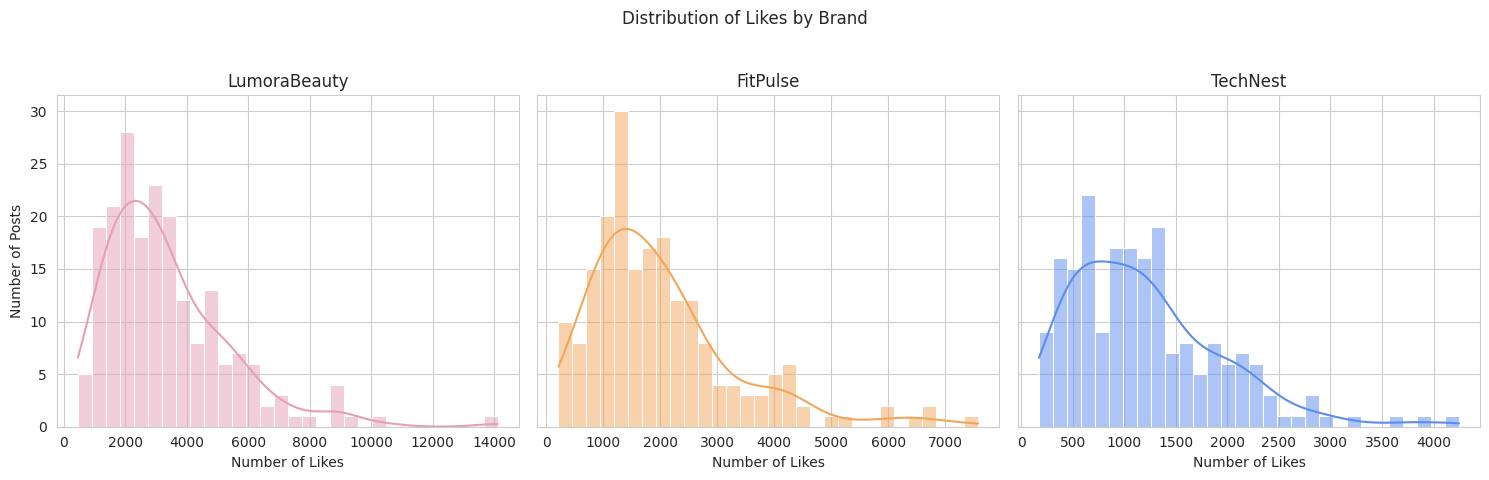

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Distribution of Likes by Brand")

for i, brand in enumerate(BRAND_ORDER):
    sns.histplot(df[df["Brand"] == brand]["Num_Likes"], bins=30, kde=True, color=BRAND_COLORS[brand], edgecolor="white", ax=axes[i])
    axes[i].set_title(brand)
    axes[i].set_xlabel("Number of Likes")
    axes[i].set_ylabel("Number of Posts")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("likes_distribution_by_brand.png", dpi=150)
plt.show()

#### Distribution of Comments

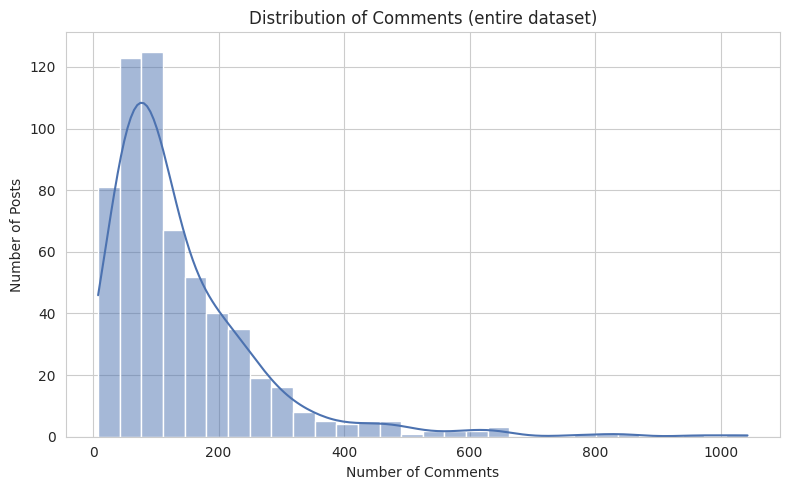

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["Num_Comments"], bins=30, kde=True, color="#4C72B0", edgecolor="white", ax=ax)
ax.set_xlabel("Number of Comments")
ax.set_ylabel("Number of Posts")
ax.set_title("Distribution of Comments (entire dataset)")
plt.tight_layout()
plt.savefig("comments_distribution_entire_dataset.png", dpi=150)
plt.show()

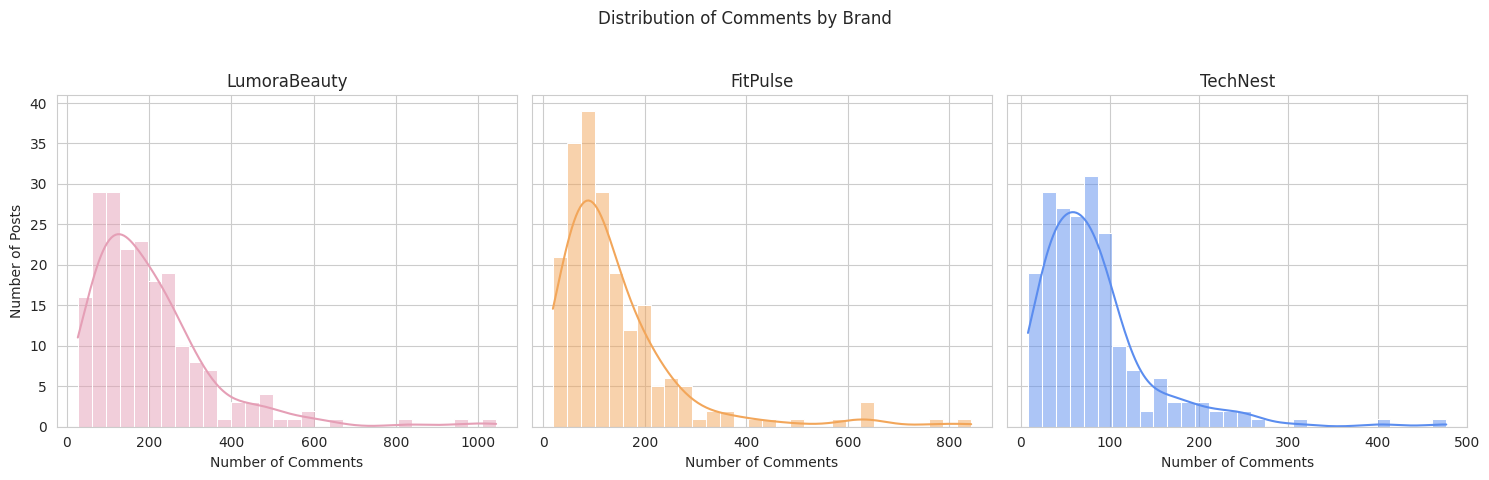

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Distribution of Comments by Brand")

for i, brand in enumerate(BRAND_ORDER):
    sns.histplot(df[df["Brand"] == brand]["Num_Comments"], bins=30, kde=True, color=BRAND_COLORS[brand], edgecolor="white", ax=axes[i])
    axes[i].set_title(brand)
    axes[i].set_xlabel("Number of Comments")
    axes[i].set_ylabel("Number of Posts")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("comments_distribution_by_brand.png", dpi=150)
plt.show()

#### Distribution of Reposts

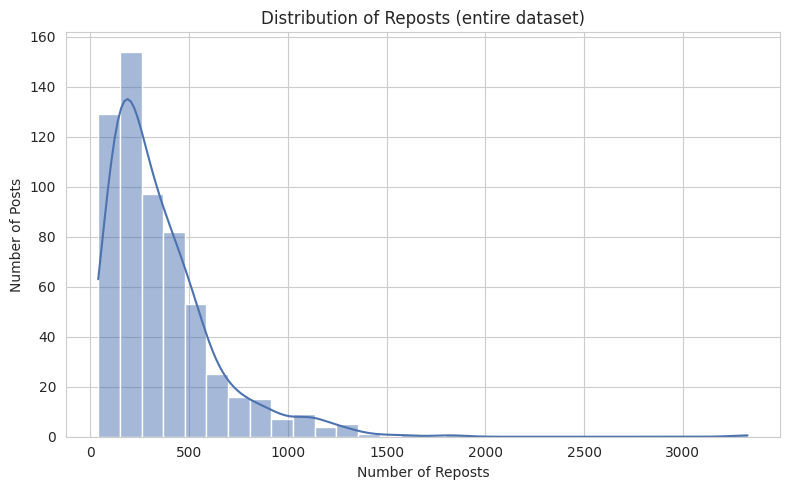

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["Num_Reposts"], bins=30, kde=True, color="#4C72B0", edgecolor="white", ax=ax)
ax.set_xlabel("Number of Reposts")
ax.set_ylabel("Number of Posts")
ax.set_title("Distribution of Reposts (entire dataset)")
plt.tight_layout()
plt.savefig("reposts_distribution_entire_dataset.png", dpi=150)
plt.show()

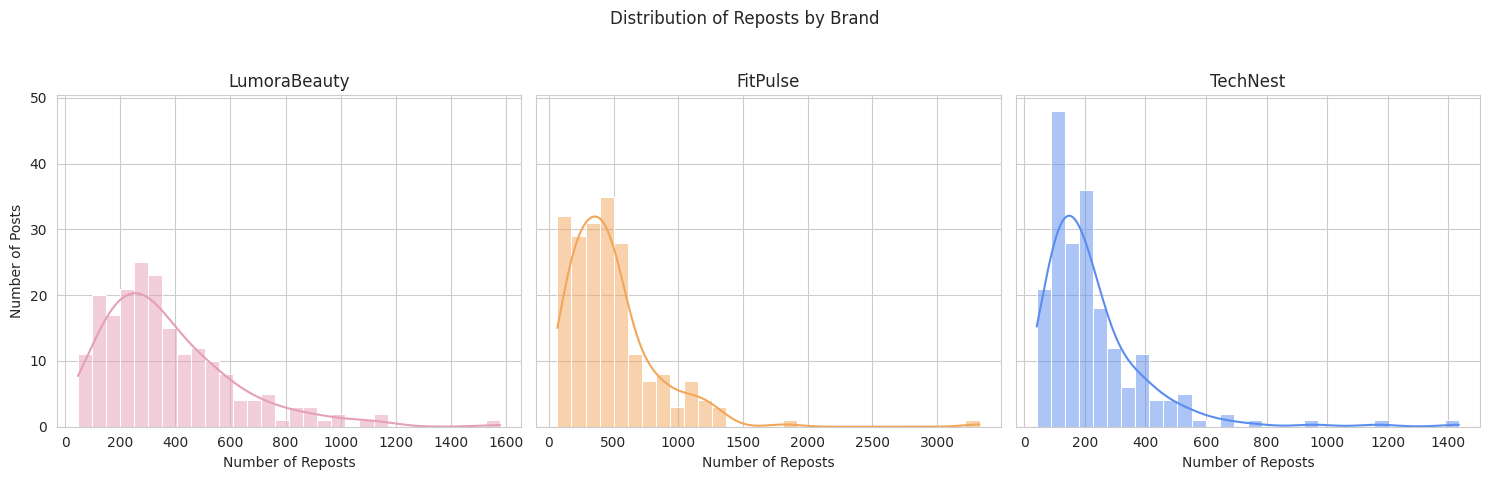

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Distribution of Reposts by Brand")

for i, brand in enumerate(BRAND_ORDER):
    sns.histplot(df[df["Brand"] == brand]["Num_Reposts"], bins=30, kde=True, color=BRAND_COLORS[brand], edgecolor="white", ax=axes[i])
    axes[i].set_title(brand)
    axes[i].set_xlabel("Number of Reposts")
    axes[i].set_ylabel("Number of Posts")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("reposts_distribution_by_brand.png", dpi=150)
plt.show()

#### Correlation

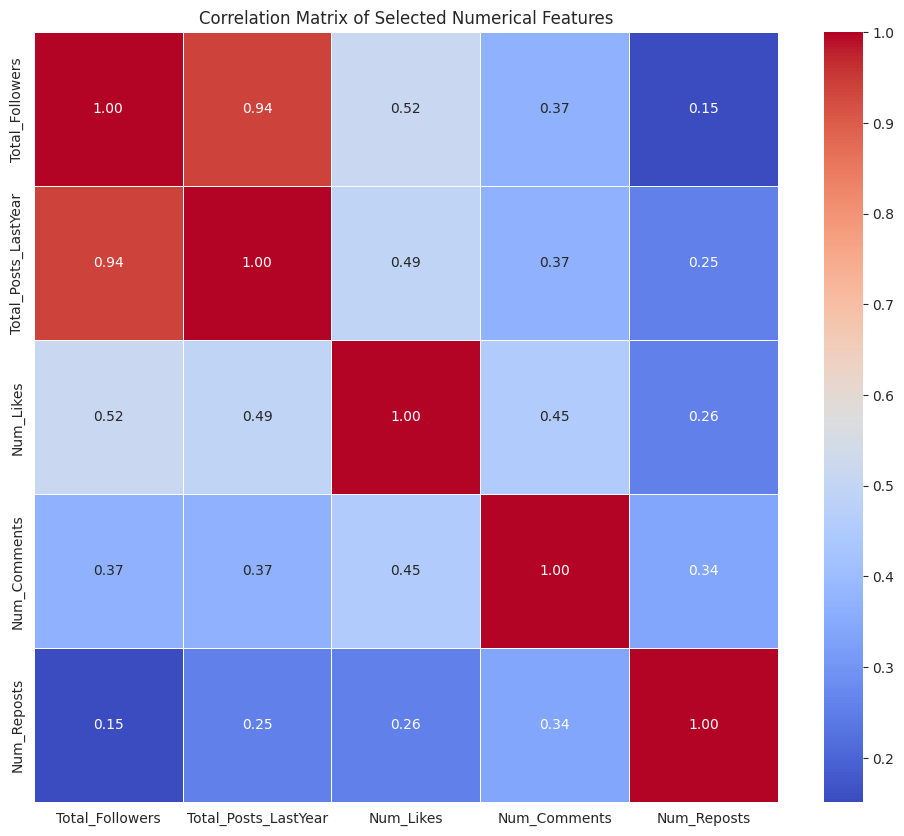

In [ ]:
features = [
    "Total_Followers", "Total_Posts_LastYear",
    "Num_Likes", "Num_Comments", "Num_Reposts"
]

corr_matrix = df[features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Correlation Matrix of Selected Numerical Features")
plt.savefig("correlation matrix", dpi=150)
plt.show()

## Q1 — Sentiment (TextBlob)

Strip emojis first (TextBlob's lexicon doesn't read them), then score polarity in [-1, +1].

In [ ]:
def strip_emojis(text):
    return re.sub(r"\s+", " ", emoji.replace_emoji(str(text), replace="")).strip()

df["Sentiment_Score"] = df["Post_Text"].apply(lambda t: TextBlob(strip_emojis(t)).sentiment.polarity)
df["Sentiment_Score"].describe().round(3)

,Sentiment_Score
count,600.000
mean,0.207
std,0.284
min,-0.800
25%,0.000
50%,0.188
75%,0.350
max,1.000


In [ ]:
# How many posts get exactly zero — TextBlob's "no opinion words" output
zero_rate = (df["Sentiment_Score"] == 0).mean()
print(f"posts scored exactly 0.0: {zero_rate:.1%}")

posts scored exactly 0.0: 20.8%


In [ ]:
df.groupby("Brand")["Sentiment_Score"].agg(["mean", "median", "std"]).round(3)

,mean,median,std
Brand,,,
FitPulse,0.119,0.136,0.312
LumoraBeauty,0.283,0.300,0.292
TechNest,0.218,0.212,0.214


In [ ]:
# Eyeball the extremes
def show(rows, label):
    print(f"\n{label}")
    for _, r in rows.iterrows():
        print(f"  [{r.Brand}] {r.Sentiment_Score:+.2f}  {r.Post_Text[:120]}")

show(df.nlargest(5, "Sentiment_Score"), "top 5")
show(df.nsmallest(5, "Sentiment_Score"), "bottom 5")


top 5
  [LumoraBeauty] +1.00  Niacinamide + Zinc = your best friends for oily, blemish-prone skin 🌿 This duo regulates sebum, minimises pores and calm
  [LumoraBeauty] +1.00  SPF is non-negotiable, even on cloudy days ☁️ UVA rays penetrate glass and clouds, accelerating skin ageing. Our Luminou
  [LumoraBeauty] +1.00  SPF is non-negotiable, even on cloudy days ☁️ UVA rays penetrate glass and clouds, accelerating skin ageing. Our Luminou
  [LumoraBeauty] +1.00  Hydration tip 💧 Hyaluronic acid works best on damp skin. Pat on after cleansing before it fully dries and watch the diff
  [LumoraBeauty] +1.00  SPF is non-negotiable, even on cloudy days ☁️ UVA rays penetrate glass and clouds, accelerating skin ageing. Our Luminou

bottom 5
  [FitPulse] -0.80  Fitness plot twist: you thought you would hate burpees, and you still do 😅 What is the exercise you cannot stand but do 
  [FitPulse] -0.80  Fitness plot twist: you thought you would hate burpees, and you still do 😅 What is the exercise y

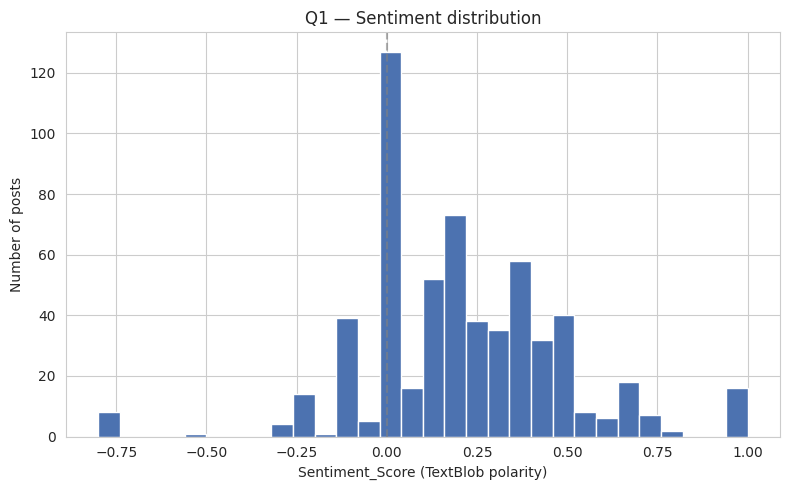

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["Sentiment_Score"], bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="grey", linestyle="--", alpha=0.6)
ax.set_xlabel("Sentiment_Score (TextBlob polarity)")
ax.set_ylabel("Number of posts")
ax.set_title("Q1 — Sentiment distribution")
plt.tight_layout()
plt.savefig("q1_sentiment_distribution.png", dpi=150)
plt.show()

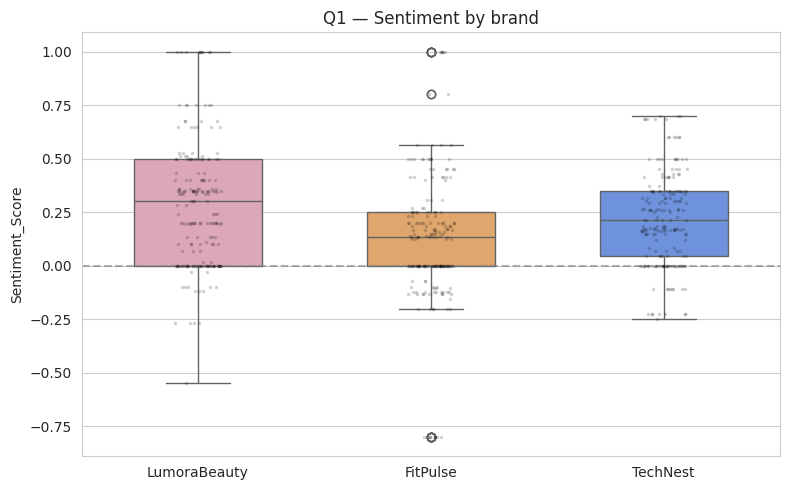

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x="Brand", y="Sentiment_Score",
    order=BRAND_ORDER, hue="Brand", palette=BRAND_COLORS, legend=False,
    width=0.55, ax=ax,
)
sns.stripplot(data=df, x="Brand", y="Sentiment_Score",
              order=BRAND_ORDER, color="black", alpha=0.18, size=2.5, ax=ax)
ax.axhline(0, color="grey", linestyle="--", alpha=0.6)
ax.set_xlabel("")
ax.set_ylabel("Sentiment_Score")
ax.set_title("Q1 — Sentiment by brand")
plt.tight_layout()
plt.savefig("q1_sentiment_by_brand.png", dpi=150)
plt.show()

## Q2 — Topic classification (zero-shot, BART)

Three labels: Informative, Entertaining, Promotional. We work in iterations:

1. Baseline zero-shot with bare labels (the textbook setup).
2. Rich label hypotheses — gives BART a clearer rubric per category, motivated by the lecture's slide on choosing your own label phrasing.
3. Keyword reconcile — high-precision CTA cues (e.g. "shop now", "% off", "link in bio") to catch promotional posts BART still missed.
4. Compare the three versions visually.

The dataset has only ~145 unique post texts (rest are repeats), so we run BART on the unique set and merge back.

In [ ]:
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
clf = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=device)
unique_posts = df["Post_Text"].drop_duplicates().tolist()
print(f"BART pipeline ready, {len(unique_posts)} unique posts to classify")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

BART pipeline ready, 145 unique posts to classify


### Part 1 — Baseline zero-shot (bare labels)

Standard setup: pass the three labels as bare strings, plain hypothesis template.

In [ ]:
LABELS_BARE = ["Informative", "Entertaining", "Promotional"]
HYPOTHESIS_BARE = "This social media post is {} content."

# Smoke test on 5 random posts before the full pass
sample = df["Post_Text"].sample(5, random_state=SEED).tolist()
for r in clf(sample, candidate_labels=LABELS_BARE, hypothesis_template=HYPOTHESIS_BARE):
    print(f"{r['labels'][0]:13} ({r['scores'][0]:.2f})  →  {r['sequence'][:90]}")

Informative   (0.50)  →  Physical exfoliants use particles to buff skin. Chemical exfoliants (AHAs/BHAs) dissolve d
Entertaining  (0.76)  →  Nothing hits like a clean desk setup ✨🖥️ Show us your workstation. We are sharing the best
Informative   (0.62)  →  PCIe 5.0 SSDs are now available but current real-world performance gains over PCIe 4.0 are
Entertaining  (0.55)  →  Current mood: applying a sheet mask and pretending it is a luxury spa day 🧖🥂 Anyone else? 
Entertaining  (0.44)  →  Introducing our bestselling Lumora Glow Serum now in a new 50ml size 🎉✨ Packed with 15% Vi


In [ ]:
t0 = time.time()
results_v1 = clf(unique_posts, candidate_labels=LABELS_BARE,
                 hypothesis_template=HYPOTHESIS_BARE, batch_size=16)
print(f"v1 done in {time.time() - t0:.1f}s")

v1 done in 7.1s


In [ ]:
# Stitch v1 results back to the full dataframe
def to_prob_dict(r):
    return dict(zip(r["labels"], r["scores"]))

v1_df = pd.DataFrame({
    "Post_Text": unique_posts,
    "Topic_Prob_v1_Informative":  [to_prob_dict(r)["Informative"]  for r in results_v1],
    "Topic_Prob_v1_Entertaining": [to_prob_dict(r)["Entertaining"] for r in results_v1],
    "Topic_Prob_v1_Promotional":  [to_prob_dict(r)["Promotional"]  for r in results_v1],
})
v1_prob_cols = [f"Topic_Prob_v1_{t}" for t in TOPICS]
v1_df["Topic_Class_v1"] = v1_df[v1_prob_cols].idxmax(axis=1).str.replace("Topic_Prob_v1_", "")
df = df.merge(v1_df, on="Post_Text", how="left")

print("v1 distribution:")
print(df["Topic_Class_v1"].value_counts())

v1 distribution:
Topic_Class_v1
Informative     417
Entertaining    170
Promotional      13
Name: count, dtype: int64


In [ ]:
print("v1 distribution by brand (%):")
pd.crosstab(df["Brand"], df["Topic_Class_v1"], normalize="index").round(3) * 100

v1 distribution by brand (%):


Topic_Class_v1,Entertaining,Informative,Promotional
Brand,,,
FitPulse,28.5,68.5,3.0
LumoraBeauty,37.5,62.5,0.0
TechNest,19.0,77.5,3.5


In [ ]:
# 20 random posts to spot-check the baseline (v1) classifier
for _, r in df.sample(20, random_state=SEED).iterrows():
    probs = {l: r[f"Topic_Prob_v1_{l}"] for l in TOPICS}
    runner_up = sorted(probs.items(), key=lambda x: -x[1])[1]
    flag = " (low confidence)" if max(probs.values()) < 0.5 else ""
    print(f"[{r.Brand:13}] {r.Topic_Class_v1:13} ({probs[r.Topic_Class_v1]:.2f}) | runner-up {runner_up[0]} ({runner_up[1]:.2f}){flag}")
    print(f"   {r.Post_Text[:110]}")
    print()

[LumoraBeauty ] Informative   (0.50) | runner-up Entertaining (0.27)
   Physical exfoliants use particles to buff skin. Chemical exfoliants (AHAs/BHAs) dissolve dead cells at a molec

[TechNest     ] Entertaining  (0.76) | runner-up Informative (0.16)
   Nothing hits like a clean desk setup ✨🖥️ Show us your workstation. We are sharing the best ones in our stories

[TechNest     ] Informative   (0.62) | runner-up Entertaining (0.22)
   PCIe 5.0 SSDs are now available but current real-world performance gains over PCIe 4.0 are minimal for most us

[LumoraBeauty ] Entertaining  (0.55) | runner-up Informative (0.37)
   Current mood: applying a sheet mask and pretending it is a luxury spa day 🧖🥂 Anyone else? Drop a 🙋 if self-car

[LumoraBeauty ] Entertaining  (0.44) | runner-up Informative (0.30) (low confidence)
   Introducing our bestselling Lumora Glow Serum now in a new 50ml size 🎉✨ Packed with 15% Vitamin C and hyaluron

[FitPulse     ] Informative   (0.64) | runner-up Entertaining (0.2

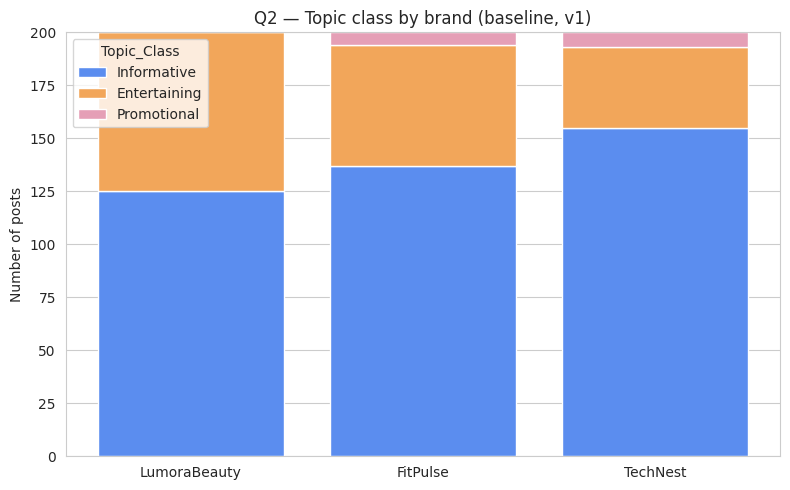

In [ ]:
# Baseline (v1) topic class by brand — counterpart to the final chart for slide comparison
ct_v1 = pd.crosstab(df["Brand"], df["Topic_Class_v1"]).reindex(BRAND_ORDER)[TOPICS]

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(ct_v1))
for lab in TOPICS:
    ax.bar(ct_v1.index, ct_v1[lab], bottom=bottom,
           color=TOPIC_PALETTE[lab], edgecolor="white", label=lab)
    bottom += ct_v1[lab].values
ax.set_ylabel("Number of posts")
ax.set_title("Q2 — Topic class by brand (baseline, v1)")
ax.legend(title="Topic_Class")
plt.tight_layout()
plt.savefig("q2_topic_by_brand_baseline.png", dpi=150)
plt.show()

### Part 2 — Rich label hypotheses

Bare labels (`"Promotional"`) give BART a vague rubric. The lecture (Session 4, slide 11) is explicit: *"You are not limited with the labels given in zero-shot — feel free to change them. This is the power of zero-shot classification."*

We pass richer phrasings that describe what each category means, then map back to the canonical three names for the output.

In [ ]:
RICH_LABELS = [
    "informative content sharing a tip, fact, tutorial, or how-to",
    "entertaining content that is humorous, relatable, or community-driven",
    "promotional content advertising a product launch, sale, discount, or call to action to buy",
]
RICH_TO_CANONICAL = {
    RICH_LABELS[0]: "Informative",
    RICH_LABELS[1]: "Entertaining",
    RICH_LABELS[2]: "Promotional",
}
HYPOTHESIS_RICH = "This post is {}."

t0 = time.time()
results_v2 = clf(unique_posts, candidate_labels=RICH_LABELS,
                 hypothesis_template=HYPOTHESIS_RICH, batch_size=16)
print(f"v2 done in {time.time() - t0:.1f}s")

v2 done in 7.3s


In [ ]:
# Map rich labels back to canonical names
def rich_to_canonical_dict(r):
    return {RICH_TO_CANONICAL[lab]: score for lab, score in zip(r["labels"], r["scores"])}

v2_df = pd.DataFrame({
    "Post_Text": unique_posts,
    "Topic_Prob_Informative":  [rich_to_canonical_dict(r)["Informative"]  for r in results_v2],
    "Topic_Prob_Entertaining": [rich_to_canonical_dict(r)["Entertaining"] for r in results_v2],
    "Topic_Prob_Promotional":  [rich_to_canonical_dict(r)["Promotional"]  for r in results_v2],
})
prob_cols = [f"Topic_Prob_{t}" for t in TOPICS]
v2_df["Topic_Class_v2"] = v2_df[prob_cols].idxmax(axis=1).str.replace("Topic_Prob_", "")
df = df.merge(v2_df, on="Post_Text", how="left")

print("v2 distribution:")
print(df["Topic_Class_v2"].value_counts())

v2 distribution:
Topic_Class_v2
Informative     292
Entertaining    253
Promotional      55
Name: count, dtype: int64


In [ ]:
print("v2 distribution by brand (%):")
pd.crosstab(df["Brand"], df["Topic_Class_v2"], normalize="index").round(3) * 100

v2 distribution by brand (%):


Topic_Class_v2,Entertaining,Informative,Promotional
Brand,,,
FitPulse,33.5,57.0,9.5
LumoraBeauty,45.0,45.5,9.5
TechNest,48.0,43.5,8.5


### Part 3 — Keyword reconcile

High-precision regex for promotional CTAs ("shop now", "link in bio", "% off", "use code", branded URLs, etc.). If a post matches and BART didn't already call it Promotional, we override. Conservative — never overrides *away* from Promotional.

The brief explicitly allows keyword-based classification as a fallback method.

In [ ]:
PROMO_PATTERNS = [
    r"\b\d+\s*%\s*off\b",
    r"\b(?:shop|buy|order)\s+now\b",
    r"\blink\s+in\s+bio\b",
    r"\buse\s+code\b",
    r"\blimited[\s\-]time\b",
    r"\bfree\s+(?:standard\s+|express\s+)?(?:shipping|delivery)\b",
    r"\bsubscribe\s+(?:and|&)\s+save\b",
    r"\bsave\s+\d+\s*%?\b",
    r"\bflash\s+sale\b",
    r"\bon\s+sale\b",
    r"\brisk[\s\-]free\b",
    r"\b(?:details|available|order|shop)\s+at\s+\w+\.com\b",
    r"\bships\s+within\b",
    r"\b(?:launch|launching|introducing|new\s+drop)\b",
    r"\bback\s+in\s+stock\b",
    r"\bpre[\s\-]?order\b",
]
PROMO_PATTERN = "|".join(PROMO_PATTERNS)

df["Promo_Cue"] = df["Post_Text"].str.contains(PROMO_PATTERN, regex=True, case=False, na=False)
df["Topic_Class"] = df["Topic_Class_v2"].copy()
override_rows = df["Promo_Cue"] & (df["Topic_Class"] != "Promotional")
df.loc[override_rows, "Topic_Class"] = "Promotional"

print(f"keyword override fired on {override_rows.sum()} of {len(df)} rows")
print(f"\nfinal distribution:")
print(df["Topic_Class"].value_counts())

keyword override fired on 92 of 600 rows

final distribution:
Topic_Class
Informative     233
Entertaining    220
Promotional     147
Name: count, dtype: int64


In [ ]:
# Sample of posts that got overridden — sanity check the rule.
# Recompute the mask from columns so this cell is safe to run independently.
overridden = df[df["Promo_Cue"] & (df["Topic_Class_v2"] != "Promotional")].drop_duplicates("Post_Text").head(8)
print("Posts overridden to Promotional:\n")
for _, r in overridden.iterrows():
    print(f"[{r.Brand}] BART said {r.Topic_Class_v2}  →  override to Promotional")
    print(f"   {r.Post_Text[:140]}\n")

Posts overridden to Promotional:

[LumoraBeauty] BART said Entertaining  →  override to Promotional
   Our ClearCalm Blemish Serum has over 10,000 five-star reviews 🙌⭐ Visible results in 72 hours or your money back. Try it risk-free. Link in b

[LumoraBeauty] BART said Informative  →  override to Promotional
   Our Lumora Radiance Kit serum plus moisturiser plus SPF is your complete brightening routine in one beautiful box 📦💛 Perfect self-gift. Link

[LumoraBeauty] BART said Informative  →  override to Promotional
   Running low on your Lumora SPF? ☀️ Do not let your skin go unprotected. Restock before you run out. Link in bio, free delivery over 35 euros

[LumoraBeauty] BART said Informative  →  override to Promotional
   Our Lumora subscription box ships monthly with 4 to 6 products curated to your skin type. Subscriptions open now. Details in link in bio.

[LumoraBeauty] BART said Informative  →  override to Promotional
   Lumora Hydra-Boost Toner is now available in a 200ml refill 

In [ ]:
print("final distribution by brand (%):")
pd.crosstab(df["Brand"], df["Topic_Class"], normalize="index").round(3) * 100

final distribution by brand (%):


Topic_Class,Entertaining,Informative,Promotional
Brand,,,
FitPulse,27.0,48.5,24.5
LumoraBeauty,37.5,35.5,27.0
TechNest,45.5,32.5,22.0


### Part 4 — Comparing the three versions

Visualise where the three iterations agree and disagree. Pie chart shows agreement rate between the naive baseline (v1) and the final classifier; bar chart shows how the per-topic distribution shifts across the three versions.

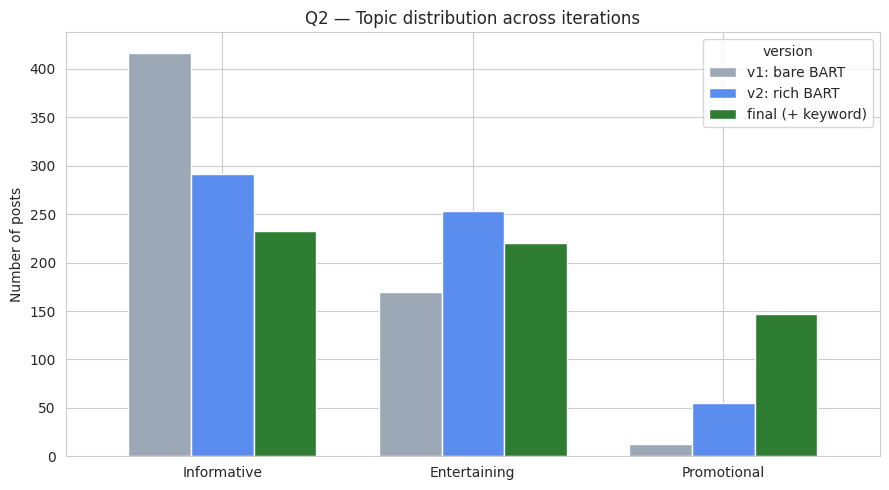

,v1: bare BART,v2: rich BART,final (+ keyword)
Informative,417,292,233
Entertaining,170,253,220
Promotional,13,55,147


In [ ]:
# Distribution comparison across versions
counts = pd.DataFrame({
    "v1: bare BART":      df["Topic_Class_v1"].value_counts(),
    "v2: rich BART":      df["Topic_Class_v2"].value_counts(),
    "final (+ keyword)":  df["Topic_Class"].value_counts(),
}).reindex(TOPICS).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
counts.plot(kind="bar", ax=ax,
            color=["#9CA8B5", "#5B8DEF", "#2E7D32"], edgecolor="white", width=0.75)
ax.set_xticklabels(counts.index, rotation=0)
ax.set_ylabel("Number of posts")
ax.set_title("Q2 — Topic distribution across iterations")
ax.legend(title="version")
plt.tight_layout()
plt.savefig("q2_iterations_comparison.png", dpi=150)
plt.show()
counts

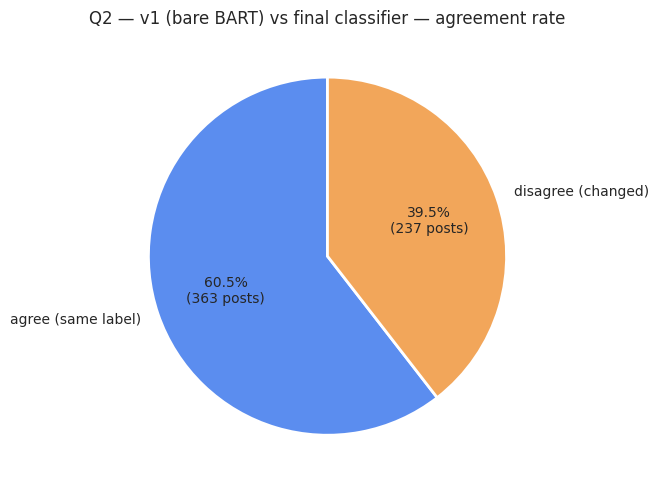

In [ ]:
# Pie chart — agreement between v1 (bare BART) and the final classifier
agreement = (df["Topic_Class_v1"] == df["Topic_Class"])
labels = ["agree (same label)", "disagree (changed)"]
sizes = [agreement.sum(), (~agreement).sum()]

fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(sizes, labels=labels, colors=["#5B8DEF", "#F2A65A"],
       autopct=lambda p: f"{p:.1f}%\n({int(p/100*sum(sizes))} posts)",
       startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Q2 — v1 (bare BART) vs final classifier — agreement rate")
plt.tight_layout()
plt.savefig("q2_v1_vs_final_agreement.png", dpi=150)
plt.show()

In [ ]:
# Where did the disagreements migrate? Cross-tab v1 prediction × final prediction,
# restricted to rows that changed
mismatch = df[df["Topic_Class_v1"] != df["Topic_Class"]]
print(f"rows changed between v1 and final: {len(mismatch)}\n")
print("transition matrix (rows = v1 said, cols = final says):")
pd.crosstab(mismatch["Topic_Class_v1"], mismatch["Topic_Class"])

rows changed between v1 and final: 237

transition matrix (rows = v1 said, cols = final says):


Topic_Class,Entertaining,Promotional
Topic_Class_v1,,
Entertaining,0,53
Informative,103,81


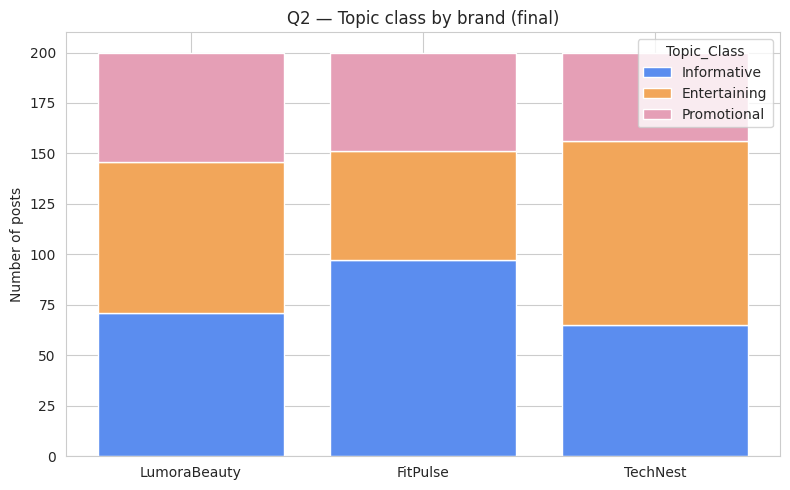

In [ ]:
# Final per-brand topic distribution — this is the chart for the slide
ct = pd.crosstab(df["Brand"], df["Topic_Class"]).reindex(BRAND_ORDER)[TOPICS]

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(ct))
for lab in TOPICS:
    ax.bar(ct.index, ct[lab], bottom=bottom,
           color=TOPIC_PALETTE[lab], edgecolor="white", label=lab)
    bottom += ct[lab].values
ax.set_ylabel("Number of posts")
ax.set_title("Q2 — Topic class by brand (final)")
ax.legend(title="Topic_Class")
plt.tight_layout()
plt.savefig("q2_topic_by_brand.png", dpi=150)
plt.show()

In [ ]:
# 20 random posts to spot-check the final result
for _, r in df.sample(20, random_state=SEED).iterrows():
    probs = {l: r[f"Topic_Prob_{l}"] for l in TOPICS}
    runner_up = sorted(probs.items(), key=lambda x: -x[1])[1]
    flag = ""
    if max(probs.values()) < 0.5:
        flag += " (low confidence)"
    if r.Topic_Class != r.Topic_Class_v2:
        flag += f" [overridden from {r.Topic_Class_v2}]"
    print(f"[{r.Brand:13}] {r.Topic_Class:13} ({probs[r.Topic_Class]:.2f}) | runner-up {runner_up[0]} ({runner_up[1]:.2f}){flag}")
    print(f"   {r.Post_Text[:110]}")
    print()

[LumoraBeauty ] Informative   (0.57) | runner-up Entertaining (0.30)
   Physical exfoliants use particles to buff skin. Chemical exfoliants (AHAs/BHAs) dissolve dead cells at a molec

[TechNest     ] Entertaining  (0.82) | runner-up Informative (0.15)
   Nothing hits like a clean desk setup ✨🖥️ Show us your workstation. We are sharing the best ones in our stories

[TechNest     ] Entertaining  (0.47) | runner-up Informative (0.36) (low confidence)
   PCIe 5.0 SSDs are now available but current real-world performance gains over PCIe 4.0 are minimal for most us

[LumoraBeauty ] Entertaining  (0.96) | runner-up Informative (0.02)
   Current mood: applying a sheet mask and pretending it is a luxury spa day 🧖🥂 Anyone else? Drop a 🙋 if self-car

[LumoraBeauty ] Promotional   (0.55) | runner-up Entertaining (0.26)
   Introducing our bestselling Lumora Glow Serum now in a new 50ml size 🎉✨ Packed with 15% Vitamin C and hyaluron

[FitPulse     ] Informative   (0.80) | runner-up Entertaining (0.1

## Q3 — Paralinguistic / Emoji Analysis

Extract emoji features from `Post_Text` using the `emoji` library: per-post counts, per-brand and per-topic frequency tables, and a distinctiveness measure (lift) to surface emojis that are characteristic of one group rather than universal. Correlation with the Q1 sentiment score closes the section. `Text_Length` is added silently as a Q4 control.

In [ ]:
from collections import Counter
from itertools import chain

df["Emoji_List"]  = df["Post_Text"].apply(lambda t: [d["emoji"] for d in emoji.emoji_list(str(t))])
df["Emoji_Count"] = df["Emoji_List"].str.len()
df["Text_Length"] = df["Post_Text"].str.split().str.len()

df[["Emoji_Count", "Text_Length"]].describe().round(1)

,Emoji_Count,Text_Length
count,600.0,600.0
mean,2.4,26.4
std,1.4,4.3
min,0.0,15.0
25%,2.0,24.0
50%,3.0,27.0
75%,4.0,29.0
max,5.0,37.0


In [ ]:
by_brand = df.groupby("Brand")["Emoji_Count"].agg(["mean", "median", "std"]).round(2)
top, bot = by_brand["mean"].idxmax(), by_brand["mean"].idxmin()
print(f"most emojis on average: {top} ({by_brand.loc[top, 'mean']:.2f})")
print(f"fewest:                 {bot} ({by_brand.loc[bot, 'mean']:.2f})")
by_brand

most emojis on average: TechNest (2.56)
fewest:                 FitPulse (2.30)


,mean,median,std
Brand,,,
FitPulse,2.30,2.0,1.45
LumoraBeauty,2.44,3.0,1.37
TechNest,2.56,3.0,1.44


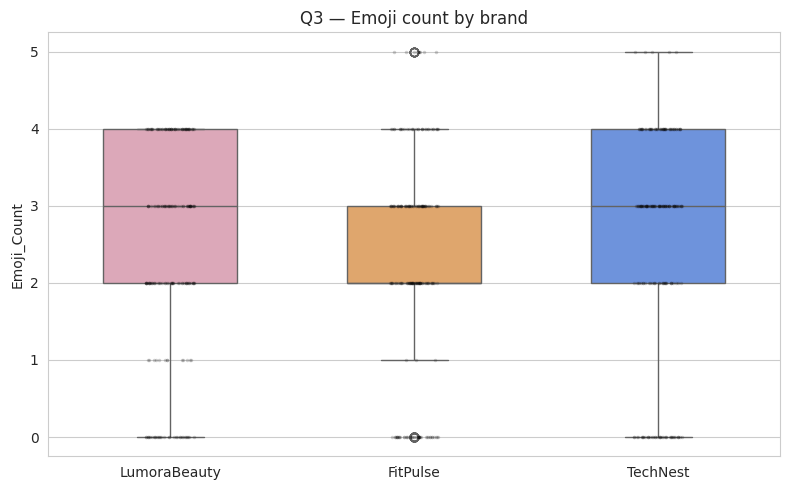

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x="Brand", y="Emoji_Count",
    order=BRAND_ORDER, hue="Brand", palette=BRAND_COLORS, legend=False,
    width=0.55, ax=ax,
)
sns.stripplot(data=df, x="Brand", y="Emoji_Count",
              order=BRAND_ORDER, color="black", alpha=0.18, size=2.5, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Emoji_Count")
ax.set_title("Q3 — Emoji count by brand")
plt.tight_layout()
plt.savefig("q3_emoji_count_by_brand.png", dpi=150)
plt.show()

In [ ]:
def top_emojis(series, n=10):
    return Counter(chain.from_iterable(series)).most_common(n)

print("Top 10 emojis per brand (raw count):")
for brand in BRAND_ORDER:
    top = top_emojis(df.loc[df["Brand"] == brand, "Emoji_List"])
    pretty = "  ".join(f"{e} ({c})" for e, c in top)
    print(f"  {brand:13} {pretty}")

Top 10 emojis per brand (raw count):
  LumoraBeauty  ✨ (89)  💛 (53)  🌸 (46)  💕 (20)  🌙 (19)  👇 (18)  🧴 (16)  🧖 (11)  👏 (10)  🥂 (9)
  FitPulse      💪 (93)  🔥 (44)  👇 (42)  😂 (22)  😅 (20)  🚫 (14)  🛋️ (14)  🙌 (12)  ⚠️ (11)  ⚡ (9)
  TechNest      💻 (63)  ⚡ (62)  👇 (51)  💡 (38)  ✅ (28)  😂 (27)  🖥️ (24)  ⚠️ (21)  ✨ (21)  😤 (18)


In [ ]:
def lift_table(series_in_group, series_overall, min_support=5, n=10):
    in_g    = Counter(chain.from_iterable(series_in_group))
    overall = Counter(chain.from_iterable(series_overall))
    total_g = sum(in_g.values())
    total   = sum(overall.values())
    rows = []
    for e, c in in_g.items():
        if c < min_support:
            continue
        p_g = c / total_g
        p_a = overall[e] / total
        rows.append((e, c, round(p_g / p_a, 2)))
    rows.sort(key=lambda r: -r[2])
    return rows[:n]

print("Distinctive emojis per brand (lift = P(emoji|brand) / P(emoji overall), min 5 uses):")
for brand in BRAND_ORDER:
    rows = lift_table(df.loc[df["Brand"] == brand, "Emoji_List"], df["Emoji_List"])
    pretty = "  ".join(f"{e} x{l}" for e, c, l in rows)
    print(f"  {brand:13} {pretty}")

Distinctive emojis per brand (lift = P(emoji|brand) / P(emoji overall), min 5 uses):
  LumoraBeauty  🌸 x2.99  💛 x2.99  🧖 x2.99  🥂 x2.99  🙋 x2.99  👏 x2.99  🧪 x2.99  🧴 x2.99  💕 x2.99  📦 x2.99
  FitPulse      🍫 x3.17  🏆 x3.17  🧠 x3.17  🚶 x3.17  🛋️ x3.17  🦵 x3.17  🏋️ x3.17  🏃 x3.17  🥚 x3.17  📉 x3.17
  TechNest      💻 x2.85  🐌 x2.85  🔒 x2.85  📡 x2.85  🖥️ x2.85  📸 x2.85  ⌨️ x2.85  💰 x2.85  💡 x2.52  ⚡ x2.49


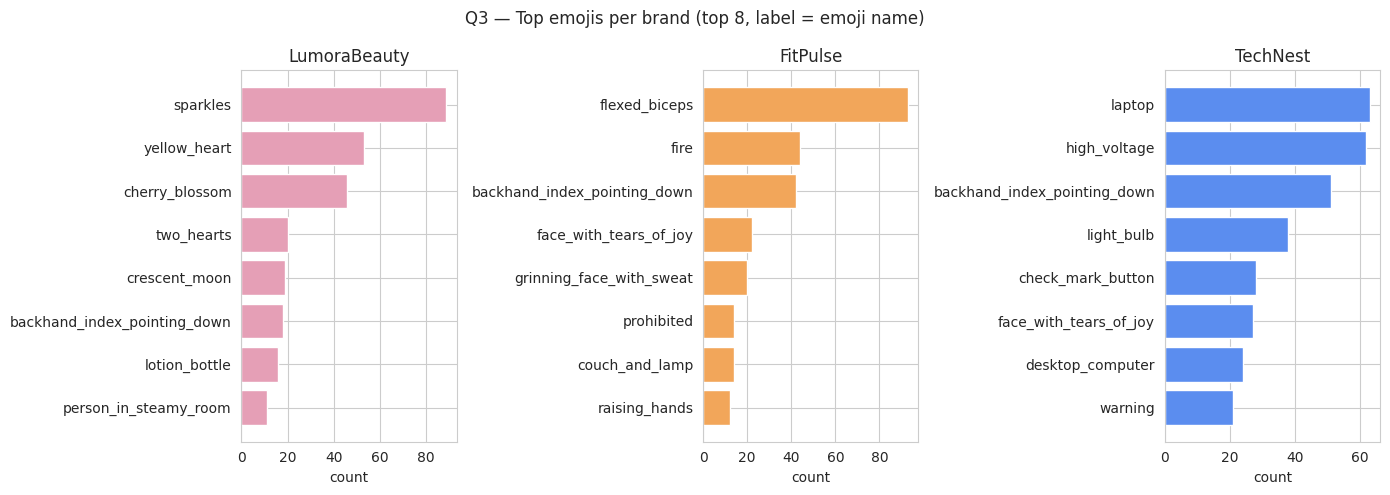

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, brand in zip(axes, BRAND_ORDER):
    top = top_emojis(df.loc[df["Brand"] == brand, "Emoji_List"], n=8)
    labels = [emoji.demojize(e).strip(":") for e, _ in top]
    counts = [c for _, c in top]
    ax.barh(range(len(top)), counts, color=BRAND_COLORS[brand], edgecolor="white")
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_title(brand)
    ax.set_xlabel("count")
plt.suptitle("Q3 — Top emojis per brand (top 8, label = emoji name)")
plt.tight_layout()
plt.savefig("q3_top_emojis_by_brand.png", dpi=150)
plt.show()

In [ ]:
print("Top 10 emojis per topic class (raw count):")
for topic in TOPICS:
    top = top_emojis(df.loc[df["Topic_Class"] == topic, "Emoji_List"])
    pretty = "  ".join(f"{e} ({c})" for e, c in top)
    print(f"  {topic:13} {pretty}")

print("\nDistinctive emojis per topic (lift, min 5 uses):")
for topic in TOPICS:
    rows = lift_table(df.loc[df["Topic_Class"] == topic, "Emoji_List"], df["Emoji_List"])
    pretty = "  ".join(f"{e} x{l}" for e, c, l in rows)
    print(f"  {topic:13} {pretty}")

Top 10 emojis per topic class (raw count):
  Informative   💪 (36)  ✨ (34)  ⚡ (30)  ⚠️ (29)  ✅ (24)  🔥 (23)  💡 (23)  👇 (19)  🌸 (14)  🌙 (14)
  Entertaining  👇 (91)  😂 (54)  ✨ (42)  💻 (38)  😅 (35)  💪 (29)  💛 (24)  🔥 (19)  🌸 (18)  🙌 (16)
  Promotional   ✨ (42)  💪 (31)  ⚡ (26)  💛 (19)  🎉 (18)  🔥 (16)  💻 (15)  🌸 (14)  🎁 (11)  🚫 (10)

Distinctive emojis per topic (lift, min 5 uses):
  Informative   🧪 x3.09  🌿 x3.09  💆 x3.09  💧 x3.09  🧠 x3.09  🚶 x3.09  🥚 x3.09  🐌 x3.09  🔒 x3.09  🏋️ x2.41
  Entertaining  🥂 x2.27  🙋 x2.27  👏 x2.27  😂 x2.27  🙈 x2.27  😍 x2.27  🦵 x2.27  📉 x2.27  📸 x2.27  ⌨️ x2.27
  Promotional   ⭐ x4.24  🎁 x4.24  📦 x4.24  🛒 x4.24  💰 x4.24  🎉 x3.82  🏆 x3.18  🚫 x2.36  🛡️ x2.36  🏠 x1.82


Emoji_Count x Sentiment_Score correlation:
  full 600 rows  | pearson +0.018   spearman +0.016
  ~145 unique    | pearson +0.035   spearman +0.053


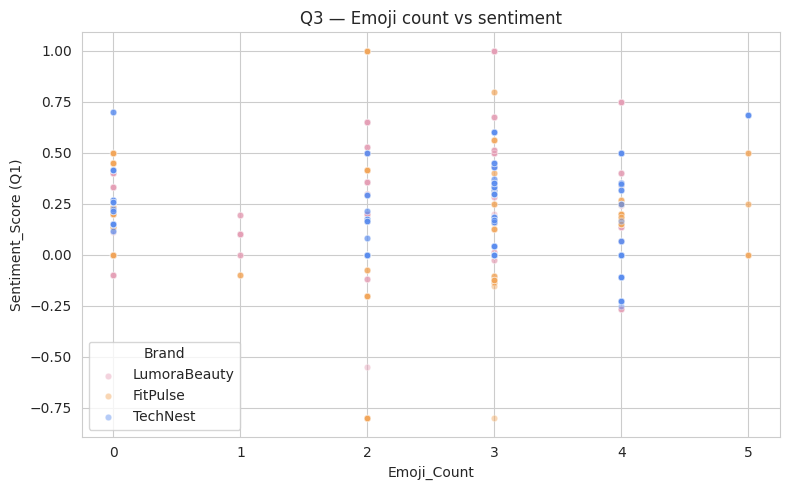

In [ ]:
pearson_full  = df["Emoji_Count"].corr(df["Sentiment_Score"], method="pearson")
spearman_full = df["Emoji_Count"].corr(df["Sentiment_Score"], method="spearman")

unique = df.drop_duplicates("Post_Text")
pearson_uniq  = unique["Emoji_Count"].corr(unique["Sentiment_Score"], method="pearson")
spearman_uniq = unique["Emoji_Count"].corr(unique["Sentiment_Score"], method="spearman")

print("Emoji_Count x Sentiment_Score correlation:")
print(f"  full 600 rows  | pearson {pearson_full:+.3f}   spearman {spearman_full:+.3f}")
print(f"  ~145 unique    | pearson {pearson_uniq:+.3f}   spearman {spearman_uniq:+.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
for brand in BRAND_ORDER:
    sub = df[df["Brand"] == brand]
    ax.scatter(sub["Emoji_Count"], sub["Sentiment_Score"],
               color=BRAND_COLORS[brand], alpha=0.45, label=brand,
               s=22, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Emoji_Count")
ax.set_ylabel("Sentiment_Score (Q1)")
ax.set_title("Q3 — Emoji count vs sentiment")
ax.legend(title="Brand")
plt.tight_layout()
plt.savefig("q3_emoji_vs_sentiment.png", dpi=150)
plt.show()

In [ ]:
print("Highest emoji counts:")
for _, r in df.nlargest(5, "Emoji_Count").iterrows():
    print(f"  [{r.Brand:13}] count={r.Emoji_Count}  {r.Post_Text[:120]}")

print("\nLowest emoji counts:")
for _, r in df.nsmallest(5, "Emoji_Count").iterrows():
    print(f"  [{r.Brand:13}] count={r.Emoji_Count}  {r.Post_Text[:120]}")

Highest emoji counts:
  [FitPulse     ] count=5  Training partner appreciation post 🤝💪 Nothing like someone who shows up, pushes you harder, and celebrates your PRs like
  [FitPulse     ] count=5  Weekend mode activated 💪🌅 Whether you are hitting a trail, pool or the gym, make it count! Share your Saturday workout b
  [FitPulse     ] count=5  That post-workout feeling is better than everything else 🔥💪 Drop a 💯 if hitting the gym at 6am and then conquering the d
  [FitPulse     ] count=5  That post-workout feeling is better than everything else 🔥💪 Drop a 💯 if hitting the gym at 6am and then conquering the d
  [FitPulse     ] count=5  Weekend mode activated 💪🌅 Whether you are hitting a trail, pool or the gym, make it count! Share your Saturday workout b

Lowest emoji counts:
  [LumoraBeauty ] count=0  Our Lumora subscription box ships monthly with 4 to 6 products curated to your skin type. Subscriptions open now. Detail
  [LumoraBeauty ] count=0  Micellar water uses tiny oil molecules su

## Q4 — Drivers of Engagement

Combine the derived NLP features (sentiment, topic class, emoji count, face-emoji indicator) with brand controls and predict engagement: Num_Likes as the primary outcome and Num_Comments as a parallel secondary model. Negative Binomial GLM with cluster-robust standard errors clustered on `Post_Text` — corrects for the within-post correlation introduced by ~145 unique posts repeated 3–10× across the 600 rows.

Q3 amendment first: add `Has_Face_Emoji`, a binary indicator for posts containing any face emoji (Smileys & Emotion / People & Body groups). Backed by Orazi 2023 (lecture page 21): face vs non-face emojis behave differently in marketing contexts.

In [ ]:
import unicodedata

def has_face(emoji_chars):
    return any("FACE" in unicodedata.name(e[0], "") for e in emoji_chars if e)

df["Has_Face_Emoji"] = df["Emoji_List"].apply(has_face)
print(f"posts with face emojis: {df['Has_Face_Emoji'].sum()} of {len(df)} ({df['Has_Face_Emoji'].mean():.1%})")
df.groupby("Brand")["Has_Face_Emoji"].mean().round(3)

posts with face emojis: 135 of 600 (22.5%)


,Has_Face_Emoji
Brand,
FitPulse,0.245
LumoraBeauty,0.175
TechNest,0.255


In [ ]:
print("Outcome dispersion (variance / mean — NB justified if >> 1):")
for col in ["Num_Likes", "Num_Comments"]:
    m, v = df[col].mean(), df[col].var()
    print(f"  {col:13} mean={m:8.1f}   var={v:12.0f}   ratio={v/m:8.1f}")

Outcome dispersion (variance / mean — NB justified if >> 1):
  Num_Likes     mean=  2186.7   var=     2903566   ratio=  1327.8
  Num_Comments  mean=   142.2   var=       16844   ratio=   118.5


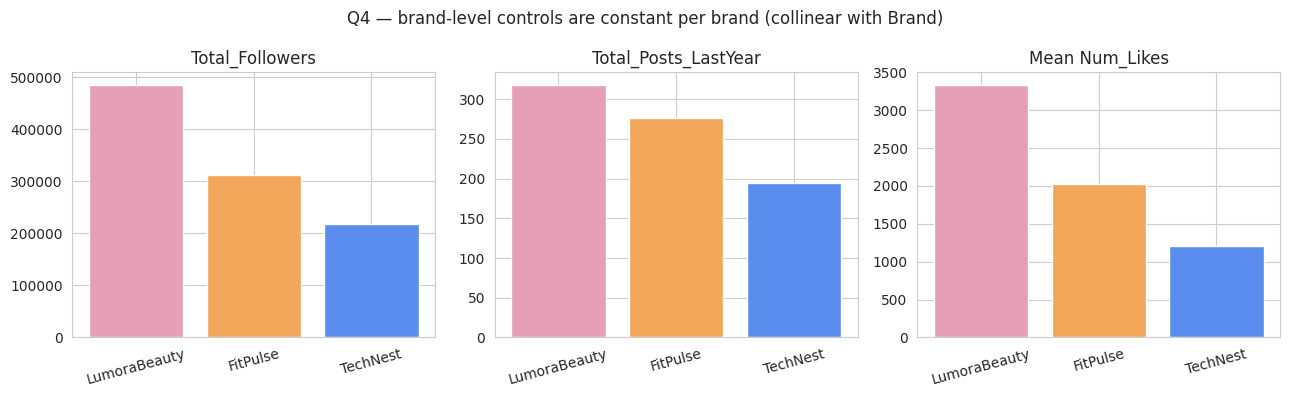

In [ ]:
agg = df.groupby("Brand").agg(
    Followers=("Total_Followers", "first"),
    Posts=("Total_Posts_LastYear", "first"),
    MeanLikes=("Num_Likes", "mean"),
).reindex(BRAND_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = ["Total_Followers", "Total_Posts_LastYear", "Mean Num_Likes"]
for ax, col, title in zip(axes, ["Followers", "Posts", "MeanLikes"], titles):
    colors = [BRAND_COLORS[b] for b in agg.index]
    ax.bar(agg.index, agg[col], color=colors, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Q4 — brand-level controls are constant per brand (collinear with Brand)")
plt.tight_layout()
plt.savefig("q4_brand_collinearity.png", dpi=150)
plt.show()

In [ ]:
import statsmodels.formula.api as smf

formula_likes = (
    "Num_Likes ~ Sentiment_Score + Emoji_Count + Has_Face_Emoji + Text_Length "
    "+ C(Topic_Class, Treatment(reference='Informative')) "
    "+ C(Brand, Treatment(reference='LumoraBeauty'))"
)
groups = pd.factorize(df["Post_Text"])[0]
m_likes = smf.negativebinomial(formula_likes, data=df).fit(
    cov_type="cluster", cov_kwds={"groups": groups}, disp=False
)
print(m_likes.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:              Num_Likes   No. Observations:                  600
Model:               NegativeBinomial   Df Residuals:                      591
Method:                           MLE   Df Model:                            8
Date:                Sat, 09 May 2026   Pseudo R-squ.:                 0.03590
Time:                        20:24:34   Log-Likelihood:                -4959.2
converged:                       True   LL-Null:                       -5143.9
Covariance Type:              cluster   LLR p-value:                 6.903e-75
                                                                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                              7.8688      0.200     39.34

In [ ]:
formula_comments = formula_likes.replace("Num_Likes", "Num_Comments")
m_comments = smf.negativebinomial(formula_comments, data=df).fit(
    cov_type="cluster", cov_kwds={"groups": groups}, disp=False
)
print(m_comments.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:           Num_Comments   No. Observations:                  600
Model:               NegativeBinomial   Df Residuals:                      591
Method:                           MLE   Df Model:                            8
Date:                Sat, 09 May 2026   Pseudo R-squ.:                 0.04537
Time:                        20:24:34   Log-Likelihood:                -3369.5
converged:                       True   LL-Null:                       -3529.7
Covariance Type:              cluster   LLR p-value:                 1.989e-64
                                                                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                              4.7563      0.261     18.23

In [ ]:
def coef_frame(model, label):
    p  = model.params
    ci = model.conf_int()
    out = pd.DataFrame({
        f"IRR_{label}":     np.exp(p),
        f"CI_low_{label}":  np.exp(ci[0]),
        f"CI_high_{label}": np.exp(ci[1]),
        f"p_{label}":       model.pvalues,
    })
    return out.drop("alpha", errors="ignore")

combined = coef_frame(m_likes, "likes").join(coef_frame(m_comments, "comments")).round(3)
combined

,IRR_likes,CI_low_likes,CI_high_likes,p_likes,IRR_comments,CI_low_comments,CI_high_comments,p_comments
Intercept,2614.313,1766.496,3869.033,0.000,116.317,69.770,193.918,0.000
Has_Face_Emoji[T.True],0.970,0.814,1.157,0.737,1.109,0.873,1.410,0.396
"C(Topic_Class, Treatment(reference='Informative'))[T.Entertaining]",1.084,0.949,1.238,0.235,1.157,0.938,1.428,0.174
"C(Topic_Class, Treatment(reference='Informative'))[T.Promotional]",1.020,0.874,1.190,0.803,1.185,0.964,1.456,0.108
"C(Brand, Treatment(reference='LumoraBeauty'))[T.FitPulse]",0.640,0.552,0.742,0.000,0.760,0.632,0.914,0.004
"C(Brand, Treatment(reference='LumoraBeauty'))[T.TechNest]",0.357,0.309,0.412,0.000,0.401,0.333,0.482,0.000
Sentiment_Score,0.938,0.779,1.130,0.501,1.262,0.986,1.615,0.064
Emoji_Count,1.207,1.163,1.252,0.000,1.257,1.189,1.330,0.000
Text_Length,0.990,0.974,1.005,0.190,0.991,0.972,1.010,0.328


In [ ]:
sig_l = m_likes.pvalues    < 0.05
sig_c = m_comments.pvalues < 0.05
sign_l = np.sign(m_likes.params)
sign_c = np.sign(m_comments.params)
idx = [v for v in m_likes.params.index if v not in ("alpha", "Intercept")]

print("Likes-only drivers (sig in likes, n.s. in comments):")
for v in idx:
    if sig_l[v] and not sig_c[v]:
        print(f"  {v:55} IRR_likes={np.exp(m_likes.params[v]):.2f}")

print("\nComments-only drivers (sig in comments, n.s. in likes):")
for v in idx:
    if sig_c[v] and not sig_l[v]:
        print(f"  {v:55} IRR_comments={np.exp(m_comments.params[v]):.2f}")

print("\nSign flips (sig in both, opposite direction):")
for v in idx:
    if sig_l[v] and sig_c[v] and sign_l[v] != sign_c[v]:
        print(f"  {v:55} IRR_likes={np.exp(m_likes.params[v]):.2f}  IRR_comments={np.exp(m_comments.params[v]):.2f}")

Likes-only drivers (sig in likes, n.s. in comments):

Comments-only drivers (sig in comments, n.s. in likes):

Sign flips (sig in both, opposite direction):


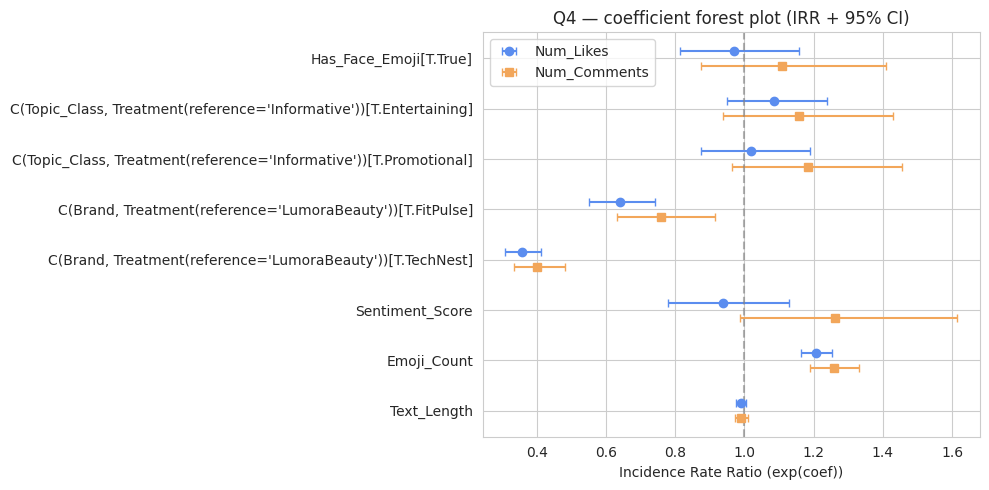

In [ ]:
def forest_data(model):
    p  = model.params.drop(["alpha", "Intercept"], errors="ignore")
    ci = model.conf_int().drop(["alpha", "Intercept"], errors="ignore")
    return np.exp(p), np.exp(ci[0]), np.exp(ci[1])

p_l, lo_l, hi_l = forest_data(m_likes)
p_c, lo_c, hi_c = forest_data(m_comments)
labels = list(p_l.index)
y = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * len(labels))))
ax.errorbar(p_l, y - 0.15, xerr=[p_l - lo_l, hi_l - p_l],
            fmt="o", color="#5B8DEF", label="Num_Likes", capsize=3)
ax.errorbar(p_c, y + 0.15, xerr=[p_c - lo_c, hi_c - p_c],
            fmt="s", color="#F2A65A", label="Num_Comments", capsize=3)
ax.axvline(1.0, color="grey", linestyle="--", alpha=0.6)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("Incidence Rate Ratio (exp(coef))")
ax.set_title("Q4 — coefficient forest plot (IRR + 95% CI)")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("q4_coefficients.png", dpi=150)
plt.show()

In [ ]:
def fit_stats(model, outcome):
    null = smf.negativebinomial(f"{outcome} ~ 1", data=df).fit(disp=False)
    return {
        "outcome": outcome,
        "n":  int(model.nobs),
        "log_lik": round(model.llf, 1),
        "AIC": round(model.aic, 1),
        "pseudo_R2_McFadden": round(1 - model.llf / null.llf, 3),
        "alpha (NB dispersion)": round(model.params["alpha"], 3),
    }

pd.DataFrame([
    fit_stats(m_likes,    "Num_Likes"),
    fit_stats(m_comments, "Num_Comments"),
]).set_index("outcome")

,n,log_lik,AIC,pseudo_R2_McFadden,alpha (NB dispersion)
outcome,,,,,
Num_Likes,600,-4959.2,9938.5,0.036,0.287
Num_Comments,600,-3369.5,6759.0,0.045,0.354


### Findings — Q4

**A1. Which derived NLP variables predict engagement?**
*(Populate from the IRR table above with one line per significant predictor — sentiment, Topic_Class dummies, Emoji_Count, Has_Face_Emoji. Read directly from `combined`.)*

**A2. Do brand-level characteristics (follower count, posting frequency) matter?**
`Total_Followers` and `Total_Posts_LastYear` take exactly one value per brand (see `q4_brand_collinearity.png`) — they are perfectly determined by Brand identity. Their effect cannot be statistically separated from the brand fixed effect. The Brand dummy coefficients in our model therefore represent the **combined** effect of brand identity, follower size, and posting frequency. To isolate follower-count effects independently, the dataset would need within-brand variation in followers, which doesn't exist here. **Yes, brand matters; whether the driver is brand size or brand strategy is not separately identifiable in this data.**

**A3. Are there factors that drive likes but not comments, or vice versa?**
*(Populate from the cell 9 delta output — that cell already structures the answer into likes-only / comments-only / sign-flip buckets.)*

**Model justification.** Both outcomes are heavily right-skewed counts (`q4_outcome_distribution.png`) with variance/mean ratios in the hundreds (cell 4) — Negative Binomial is the appropriate family. Cluster-robust standard errors clustered on `Post_Text` correct for the within-post correlation introduced by 600 rows = ~145 unique posts × 3–10 reps. NB dispersion `α` reported in the fit-stats table.

**Caveats for Q5/Q6.** Coefficients are population-average; per-brand differences are out of scope here and addressed via interactions or brand-stratified models in Q5.

## Q5 — Brand Differences

Do engagement drivers differ across the three brands? Two approaches: (1) a single interaction model that adds Brand × NLP interaction terms to the Q4 spec — tested jointly via likelihood ratio against the Q4 baseline; (2) the Q4 spec re-fit separately on each brand for a coefficient-by-coefficient comparison. Likes only here; comments deferred to appendix.

In [ ]:
formula_int = (
    formula_likes
    + " + Sentiment_Score:C(Brand, Treatment(reference='LumoraBeauty'))"
    + " + C(Topic_Class, Treatment(reference='Informative')):C(Brand, Treatment(reference='LumoraBeauty'))"
    + " + Emoji_Count:C(Brand, Treatment(reference='LumoraBeauty'))"
    + " + Has_Face_Emoji:C(Brand, Treatment(reference='LumoraBeauty'))"
)

m_int_likes = smf.negativebinomial(formula_int, data=df).fit(
    cov_type="cluster", cov_kwds={"groups": groups}, disp=False
)
print(m_int_likes.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:              Num_Likes   No. Observations:                  600
Model:               NegativeBinomial   Df Residuals:                      581
Method:                           MLE   Df Model:                           18
Date:                Sat, 09 May 2026   Pseudo R-squ.:                 0.03726
Time:                        20:24:36   Log-Likelihood:                -4952.2
converged:                      False   LL-Null:                       -5143.9
Covariance Type:              cluster   LLR p-value:                 2.748e-70
                                                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# LR test: interaction model vs Q4 baseline. df = number of added params.
from scipy.stats import chi2

lr_stat = 2 * (m_int_likes.llf - m_likes.llf)
df_added = int(m_int_likes.df_model - m_likes.df_model)
p_lr = chi2.sf(lr_stat, df_added)
print(f"LR test (Brand × NLP interactions on Likes): "
      f"chi2={lr_stat:.2f}, df={df_added}, p={p_lr:.4f}")

LR test (Brand × NLP interactions on Likes): chi2=14.02, df=10, p=0.1719


In [ ]:
# Per-brand NB models. NB α can fail to identify at n=200; fall back to Poisson on that brand and tag it.
BRANDS = ["LumoraBeauty", "FitPulse", "TechNest"]
TOPIC_LEVELS = ["Informative", "Entertaining", "Promotional"]
formula_brand = (
    "Num_Likes ~ Sentiment_Score + Emoji_Count + Has_Face_Emoji + Text_Length "
    "+ C(Topic_Class, Treatment(reference='Informative'))"
)

per_brand = {}
for b in BRANDS:
    sub = df[df["Brand"] == b].copy()
    # Pin all 3 topic levels so the reference contrast works even if a subset lacks one level
    sub["Topic_Class"] = pd.Categorical(sub["Topic_Class"], categories=TOPIC_LEVELS)
    g = pd.factorize(sub["Post_Text"])[0]
    try:
        m = smf.negativebinomial(formula_brand, data=sub).fit(
            cov_type="cluster", cov_kwds={"groups": g}, disp=False
        )
        family = "NegBin"
    except Exception as e:
        print(f"NB failed for {b} ({e.__class__.__name__}); falling back to Poisson")
        m = smf.poisson(formula_brand, data=sub).fit(
            cov_type="cluster", cov_kwds={"groups": g}, disp=False
        )
        family = "Poisson (NB failed)"
    per_brand[b] = {"model": m, "family": family, "n": int(m.nobs)}
    print(f"{b:13} family={family:22} n={m.nobs:.0f}  llf={m.llf:.1f}  "
          f"alpha={m.params.get('alpha', float('nan')):.3f}")

LumoraBeauty  family=NegBin                 n=200  llf=-1742.4  alpha=0.251
FitPulse      family=NegBin                 n=200  llf=-1659.7  alpha=0.310
TechNest      family=NegBin                 n=200  llf=-1544.2  alpha=0.271


In [ ]:
# Tidy coefficient table: one row per (brand, predictor) with IRR, 95% CI, p.
def tidy_coefs(model, brand, family):
    p  = model.params.drop(["alpha", "Intercept"], errors="ignore")
    ci = model.conf_int().drop(["alpha", "Intercept"], errors="ignore")
    return pd.DataFrame({
        "Brand":     brand,
        "Predictor": p.index,
        "IRR":       np.exp(p.values),
        "CI_low":    np.exp(ci[0].values),
        "CI_high":   np.exp(ci[1].values),
        "p":         model.pvalues.drop(["alpha", "Intercept"], errors="ignore").values,
        "Family":    family,
    })

coefs_q5 = pd.concat(
    [tidy_coefs(d["model"], b, d["family"]) for b, d in per_brand.items()],
    ignore_index=True,
)
coefs_q5.round(3)

,Brand,Predictor,IRR,CI_low,CI_high,p,Family
0,LumoraBeauty,Has_Face_Emoji[T.True],0.811,0.679,0.969,0.021,NegBin
1,LumoraBeauty,"C(Topic_Class, Treatment(reference='Informativ...",0.875,0.738,1.037,0.123,NegBin
2,LumoraBeauty,"C(Topic_Class, Treatment(reference='Informativ...",0.851,0.688,1.052,0.135,NegBin
3,LumoraBeauty,Sentiment_Score,0.870,0.699,1.082,0.210,NegBin
4,LumoraBeauty,Emoji_Count,1.263,1.177,1.354,0.000,NegBin
5,LumoraBeauty,Text_Length,0.964,0.945,0.985,0.001,NegBin
6,FitPulse,Has_Face_Emoji[T.True],1.129,0.859,1.485,0.385,NegBin
7,FitPulse,"C(Topic_Class, Treatment(reference='Informativ...",1.223,0.925,1.617,0.158,NegBin
8,FitPulse,"C(Topic_Class, Treatment(reference='Informativ...",1.173,0.907,1.516,0.224,NegBin
9,FitPulse,Sentiment_Score,1.108,0.785,1.564,0.560,NegBin


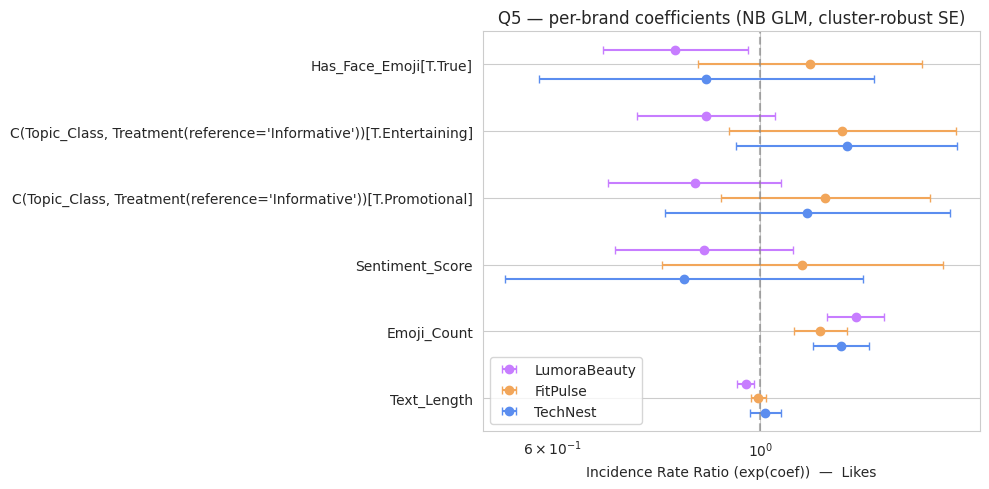

In [ ]:
# Forest plot — IRR per predictor across the three brands.
preds = list(per_brand["LumoraBeauty"]["model"].params.drop(["alpha", "Intercept"], errors="ignore").index)
colors = {"LumoraBeauty": "#C77DFF", "FitPulse": "#F2A65A", "TechNest": "#5B8DEF"}
offsets = {"LumoraBeauty": -0.22, "FitPulse": 0.0, "TechNest": 0.22}

fig, ax = plt.subplots(figsize=(10, max(5, 0.55 * len(preds))))
y = np.arange(len(preds))
for b, off in offsets.items():
    sub = coefs_q5[coefs_q5["Brand"] == b].set_index("Predictor").reindex(preds)
    ax.errorbar(
        sub["IRR"], y + off,
        xerr=[sub["IRR"] - sub["CI_low"], sub["CI_high"] - sub["IRR"]],
        fmt="o", color=colors[b], label=b, capsize=3,
    )
ax.axvline(1.0, color="grey", linestyle="--", alpha=0.6)
ax.set_yticks(y); ax.set_yticklabels(preds)
ax.set_xlabel("Incidence Rate Ratio (exp(coef))  —  Likes")
ax.set_title("Q5 — per-brand coefficients (NB GLM, cluster-robust SE)")
ax.set_xscale("log")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("q5_coef_by_brand.png", dpi=150)
plt.show()

In [ ]:
# Slide answers.
sent_irrs = {b: np.exp(d["model"].params["Sentiment_Score"]) for b, d in per_brand.items()}
sent_ps   = {b: d["model"].pvalues["Sentiment_Score"]         for b, d in per_brand.items()}
strongest = max(sent_irrs, key=sent_irrs.get)
print("Sentiment IRR per brand (Likes):")
for b, v in sent_irrs.items():
    print(f"  {b:13} IRR={v:.3f}  p={sent_ps[b]:.3f}")
print(f"-> strongest sentiment effect: {strongest} (IRR={sent_irrs[strongest]:.3f})")

# Promo IRR per brand + joint interaction test for Topic_Class × Brand from m_int_likes.
promo_key = "C(Topic_Class, Treatment(reference='Informative'))[T.Promotional]"
print("\nPromotional IRR per brand (vs Informative, Likes):")
for b, d in per_brand.items():
    irr = np.exp(d["model"].params[promo_key])
    p   = d["model"].pvalues[promo_key]
    print(f"  {b:13} IRR={irr:.3f}  p={p:.3f}")

topic_brand_terms = [t for t in m_int_likes.params.index
                    if t.startswith("C(Topic_Class") and ":C(Brand" in t]
wald_topic_brand = m_int_likes.wald_test(topic_brand_terms, scalar=True)
print(f"\nJoint test: Topic_Class × Brand interactions  "
      f"chi2={float(wald_topic_brand.statistic):.2f}, "
      f"df={int(wald_topic_brand.df_denom) if wald_topic_brand.df_denom else len(topic_brand_terms)}, "
      f"p={float(wald_topic_brand.pvalue):.4f}")

Sentiment IRR per brand (Likes):
  LumoraBeauty  IRR=0.870  p=0.210
  FitPulse      IRR=1.108  p=0.560
  TechNest      IRR=0.829  p=0.401
-> strongest sentiment effect: FitPulse (IRR=1.108)

Promotional IRR per brand (vs Informative, Likes):
  LumoraBeauty  IRR=0.851  p=0.135
  FitPulse      IRR=1.173  p=0.224
  TechNest      IRR=1.122  p=0.520

Joint test: Topic_Class × Brand interactions  chi2=3.85, df=4, p=0.4273


### Findings — Q5

**A1. Are the drivers of engagement the same across brands?**  
*(Read from the LR-test cell — joint Brand × NLP interactions p-value. If p < 0.05 the drivers differ; if not, the data is consistent with a shared driver structure.)*

**A2. For which brand does sentiment have the strongest effect on engagement?**  
*(Read from the per-brand IRR printout. If two CIs overlap heavily, report "no detectable difference" rather than picking a winner.)*

**A3. Are promotional posts equally effective across all three brands?**  
*(Read from the per-brand `Topic_Class[T.Promotional]` IRR comparison plus the joint Wald test on `Topic_Class × Brand` from the interaction model.)*

**Caveats.** n=200 per brand corresponds to ~50 unique post texts after the duplicate structure — cluster-robust SEs on `Post_Text` keep inference honest but CIs are wider than naive SEs would suggest. Any per-brand fit that fell back to Poisson is tagged in the `coefs_q5` table — read those rows with the caveat that overdispersion isn't being modelled for that brand.